<a href="https://colab.research.google.com/github/Anushka-2906/BEE/blob/main/Q1_Fragment_length_frequency_%2B_rescaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1. Fragment Length Frequency + Rescaling

Mounted at /content/drive
[INFO] BED file located at: /content/drive/MyDrive/bee coding/query.bed


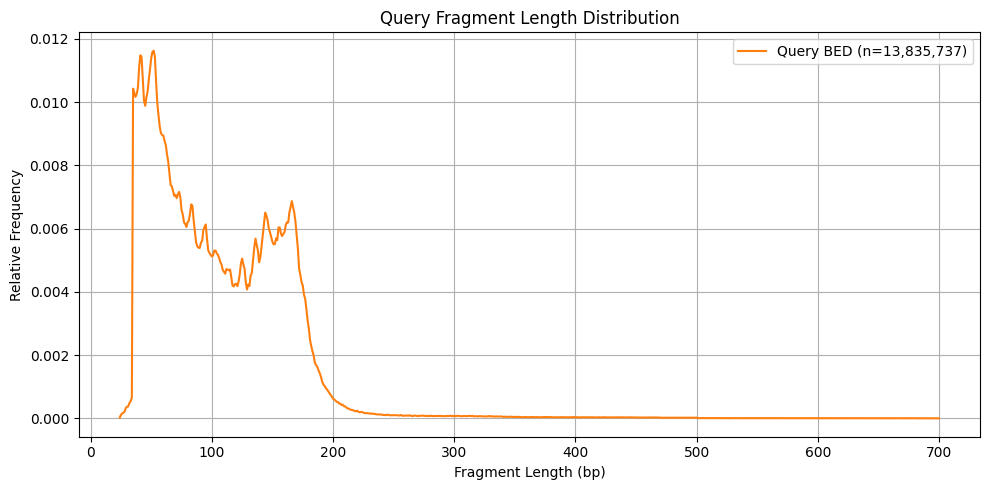

In [ ]:
# Step 1: Connect Google Drive
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# Step 2: Find the BED file
import os

def locate_file(filename, search_path):
    for dirpath, _, filenames in os.walk(search_path):
        if filename in filenames:
            return os.path.join(dirpath, filename)
    raise FileNotFoundError(f"File '{filename}' not found in {search_path}")

drive_path = "/content/drive/MyDrive/bee coding"
bed_file_name = "query.bed"

bed_file_path = locate_file(bed_file_name, drive_path)
print(f"[INFO] BED file located at: {bed_file_path}")

# Step 3: Extract fragment lengths
from collections import Counter

def parse_bed_lengths(file_path):
    lengths = []
    with open(file_path) as file:
        for line in file:
            if not line.strip() or line.startswith("#"):
                continue
            tokens = line.strip().split()
            try:
                start, end = int(tokens[1]), int(tokens[2])
                lengths.append(end - start)
            except (ValueError, IndexError):
                continue
    return lengths

fragment_sizes = parse_bed_lengths(bed_file_path)
fragment_count = Counter(fragment_sizes)

# Step 4: Normalize and store frequency
def normalize_frequencies(counts):
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

normalized_freq = normalize_frequencies(fragment_count)
x_query = sorted(normalized_freq)
y_query = [normalized_freq[k] for k in x_query]

# Step 5: Plot Query Fragment Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(x_query, y_query, label=f"Query BED (n={len(fragment_sizes):,})", color='tab:orange')
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Relative Frequency")
plt.title("Query Fragment Length Distribution")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 Rescaling Query to Match Reference Histogram

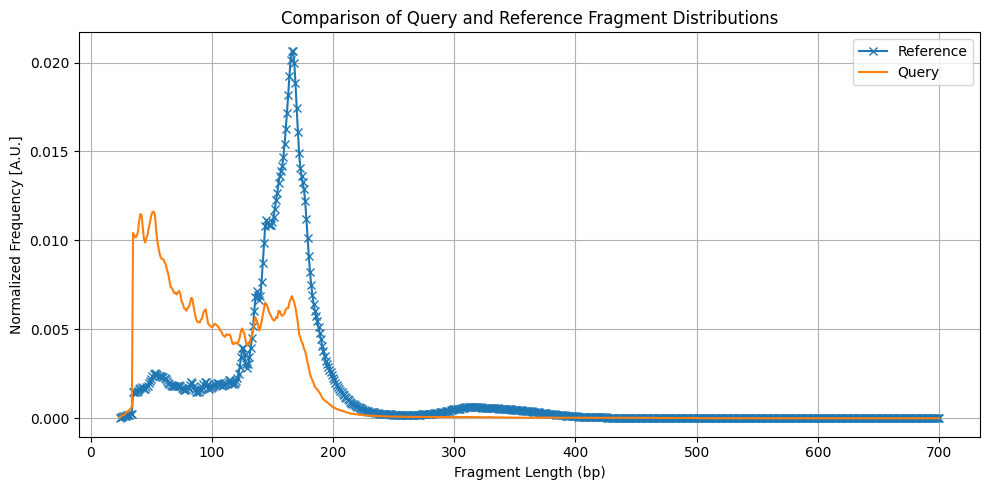

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load reference.hist file
reference_path = '/content/drive/MyDrive/bee coding/reference.hist'  # Update if needed
reference = pd.read_csv(reference_path, sep="\t", header=None, comment="#")
reference.columns = ['Length', 'Count']

# Normalize reference frequencies
ref_total = reference['Count'].sum()
reference['Normalized'] = reference['Count'] / ref_total

# Step 2: Prepare query data from previous code
# Assuming `normalized_freq` is already defined
sorted_query = sorted(normalized_freq.items())
query_lengths, query_norm = zip(*sorted_query)

# Step 3: Plot reference vs query distributions
plt.figure(figsize=(10, 5))

# Reference line with cross markers
plt.plot(reference['Length'], reference['Normalized'], label='Reference', color='tab:blue', marker='x')

# Query line without marker
plt.plot(query_lengths, query_norm, label='Query', color='tab:orange')

plt.legend()
plt.title("Comparison of Query and Reference Fragment Distributions")
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency [A.U.]")
plt.grid(True)
plt.tight_layout()
plt.show()
